# Initialization 

These are the models we've chosen for the demonstration: 
- voyage-large-2, VoyageAI
- text-embedding-3-large, OpenAI

Общего назначения

- https://huggingface.co/Alibaba-NLP/gte-large-en-v1.5
- https://huggingface.co/jinaai/jina-embeddings-v3
- https://huggingface.co/Marqo/marqo-chimera-arctic-bge-m — так и не получилось справиться

Биологические 

- https://huggingface.co/ls-da3m0ns/bge_large_medical
- https://huggingface.co/abhinand/MedEmbed-small-v0.1
- https://huggingface.co/pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb

Как выбирали: 

- не хотим локальные ллм, поэтому смотрим маленькие модели 
- мы смотрим на лицензию (лучше апач 2.0, МИТ может быть)
- мы смотрим на размерность векторов, то есть, 1500-3000 оптимум

Убрать раздел про кластеризацию 

Показать Денису раздел "как эмбеддинги и документы работают вместе?" — и либо вернуть это в рамки качественного анализа, либо уже сделать статтест и тогда сделать его аккуратно

токенайзер: аутотокенайзер дроп претрейнд для всех

Попробовать эти термины: 
- Desmopressin
- Ehlers–Danlos
- esophagogastroduodenoscopy
- cystinuria
- Willebrand disease
- angiohemophilia
- Dicynone

In [1]:
import os
import yaml
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

from tqdm.auto import tqdm

os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [2]:
OPEN_AI_KEY = os.getenv('OPEN_AI_KEY')
VOYAGE_AI_KEY = os.getenv('VOYAGE_AI_KEY')

## Voyage
https://docs.voyageai.com/docs/embeddings

In [3]:
import voyageai

vo = voyageai.Client(api_key=VOYAGE_AI_KEY)

def get_voyageai(texts):
    embeddings = vo.embed(texts, model="voyage-large-2", input_type="document").embeddings
    return embeddings

In [4]:
# from transformers import AutoTokenizer

# voyage_tokenizer = AutoTokenizer.from_pretrained('voyageai/voyage-3')

## Alibaba

In [5]:
from transformers import AutoModel, AutoTokenizer
import torch.nn.functional as F

tokenizer_alibaba = AutoTokenizer.from_pretrained('Alibaba-NLP/gte-large-en-v1.5')
model_alibaba = AutoModel.from_pretrained('Alibaba-NLP/gte-large-en-v1.5', trust_remote_code=True)

def get_alibaba(texts):
    batch_dict_alibaba = tokenizer_alibaba(texts, max_length=8192, padding=True, truncation=True, return_tensors='pt')
    outputs_alibaba = model_alibaba(**batch_dict_alibaba)
    embeddings_alibaba = F.normalize(outputs_alibaba.last_hidden_state[:, 0], p=2, dim=1).tolist()
    return embeddings_alibaba

## Jina

In [6]:
from transformers import AutoModel, AutoTokenizer
import torch
import numpy as np
from torch.nn.functional import normalize

tokenizer_jina = AutoTokenizer.from_pretrained("jinaai/jina-embeddings-v3", trust_remote_code=True)
model_jina = AutoModel.from_pretrained(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True, 
    revision="main"
)

def get_jina(texts, task="text-matching", max_length=8192, truncate_dim=None):
    encoded_input_jina = tokenizer_jina(
        texts, padding=True, truncation=True, max_length=max_length, return_tensors='pt'
    )
    with torch.inference_mode():
        embeddings_jina = model_jina.encode(
            texts, task=task, max_length=max_length, truncate_dim=truncate_dim
        )
    embeddings_jina = normalize(torch.tensor(embeddings_jina), p=2, dim=1).numpy()
    return embeddings_jina

## Marqo

## OpenAI

https://platform.openai.com/docs/guides/embeddings#embedding-models

In [7]:
from openai import OpenAI

client = OpenAI(api_key=OPEN_AI_KEY)

def get_openai(texts):
    response = client.embeddings.create(input=texts, model="text-embedding-3-large")
    return [item.embedding for item in response.data]

In [8]:
# import tiktoken

# openai_tokenizer = tiktoken.encoding_for_model("text-embedding-3-large")

## BioBert

In [9]:
from transformers import AutoTokenizer, AutoModel
import torch

def mean_pooling_biobert(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

tokenizer_biobert = AutoTokenizer.from_pretrained('pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb')
model_biobert = AutoModel.from_pretrained('pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb')

def get_biobert(texts):
    encoded_input_biobert = tokenizer_biobert(texts, padding=True, truncation=True, max_length=512, return_tensors='pt')
    with torch.no_grad():
        model_output_biobert = model_biobert(**encoded_input_biobert)
    embeddings_biobert = mean_pooling_biobert(model_output_biobert, encoded_input_biobert['attention_mask'])
    embeddings_biobert = torch.nn.functional.normalize(embeddings_biobert, p=2, dim=1).tolist()
    return embeddings_biobert

## MedEmbed

In [10]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

tokenizer_medembed = AutoTokenizer.from_pretrained('abhinand/MedEmbed-small-v0.1')
model_medembed = AutoModel.from_pretrained('abhinand/MedEmbed-small-v0.1')

def mean_pooling_medembed(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

def get_medembed(texts):
    encoded_input_medembed = tokenizer_medembed(texts, padding=True, truncation=True, return_tensors='pt')
    with torch.no_grad():
        model_output_medembed = model_medembed(**encoded_input_medembed)
    embeddings_medembed = mean_pooling_medembed(model_output_medembed, encoded_input_medembed['attention_mask'])
    embeddings_medembed = F.normalize(embeddings_medembed, p=2, dim=1).tolist()
    return embeddings_medembed

In [11]:
methods = [
    ("openai", get_openai, 1000),
    ("voyage", get_voyageai, 100),
    # ("alibaba", get_alibaba, 8),
    # ("jina", get_jina, 8),
    # ("biobert", get_biobert, 8),
    # ("medembed", get_medembed, 8)
]

In [12]:
def get_embeddings(texts, model, method, batch_size=100):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f"Processing {model}"):
        batch_texts = texts[i:i + batch_size]
        batch_embeddings = method(batch_texts)
        embeddings.extend(batch_embeddings) 
    return embeddings

# Queries embeddings

In [13]:
queries_pairs = [
    ("Сonnection between LDH markers and persistent exhaustion", "How are lactate dehydrogenase levels and chronic fatigue related?"),
    ("What published data is available for impact on daily activities with anti-C5 therapy?", "Is there evidence on how C5i impacts patients' ability to perform daily tasks?"),
    ("Is fingolimod a comparable alternative to dimethyl fumarate in multiple sclerosis management?", "Can Gilenya be used as a replacement for Tecfidera in treating multiple sclerosis?"),
    ("Addressing IVN in the treatment approach for PNH.", "Intravascular hemolysis as a factor in managing paroxysmal nocturnal hemoglobinuria."),
    ("Do high D dimer levels influence the risk of developing blood clots?", "What is the relationship between elevated D-dimer levels and thrombosis risk?"),
    ("How long have you been ill?", "Since when have you been experiencing these symptoms?"),
    ("Optical coherence tomography applications in diagnosing retinal diseases.", "What is the use of OCT in clinical assessments for retinal disorders?"),
    ("Symptoms of anemia?", "How does anemia manifest?"),
    ("The advantages of maintaining a fitness routine.", "What are the health benefits of regular physical activity")
]

In [14]:
queries_df = pd.DataFrame(queries_pairs, columns=["question 1", "question 2"])
queries_df.head()

,question 1,question 2
0,Сonnection between LDH markers and persistent ...,How are lactate dehydrogenase levels and chron...
1,What published data is available for impact on...,Is there evidence on how C5i impacts patients'...
2,Is fingolimod a comparable alternative to dime...,Can Gilenya be used as a replacement for Tecfi...
3,Addressing IVN in the treatment approach for PNH.,Intravascular hemolysis as a factor in managin...
4,Do high D dimer levels influence the risk of d...,What is the relationship between elevated D-di...


Processing openai:   0%|          | 0/1 [00:00<?, ?it/s]

Processing openai:   0%|          | 0/1 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/1 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/1 [00:00<?, ?it/s]

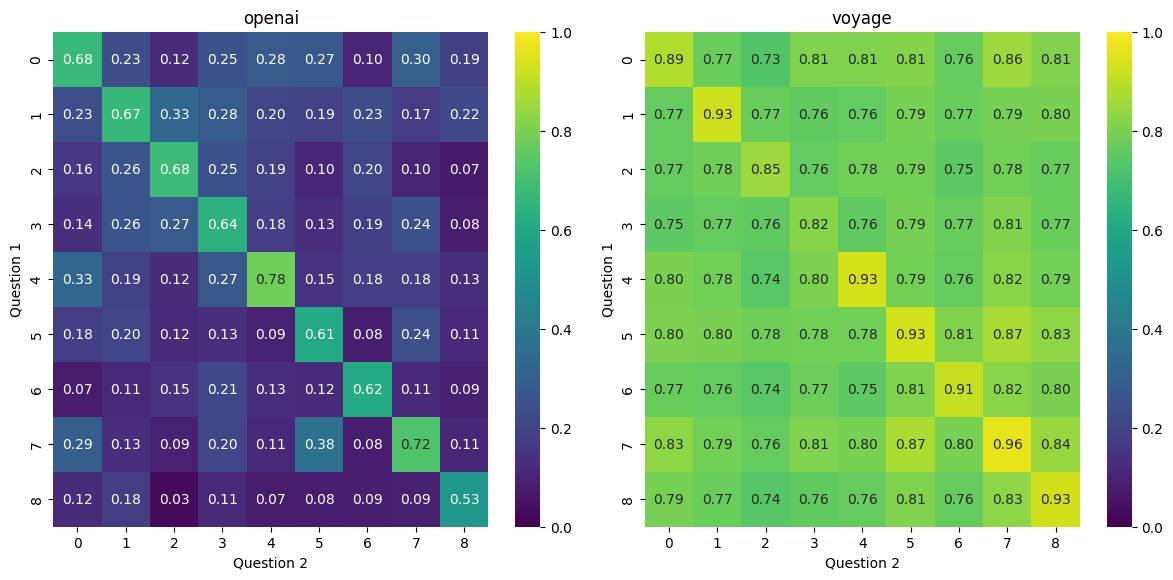

In [15]:
plt.figure(figsize=(18, 11))

for i, (model, method, _) in enumerate(methods, start=1):   
    embeddings_q1 = get_embeddings(queries_df["question 1"].tolist(), model, method)
    embeddings_q2 = get_embeddings(queries_df["question 2"].tolist(), model, method)

    similarity_matrix = cosine_similarity(embeddings_q1, embeddings_q2)
    
    plt.subplot(2, 3, i)  # line, columns, i
    sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap='viridis', cbar=True, vmin=0, vmax=1)
    plt.title(model)
    
    plt.xlabel('Question 2')
    plt.ylabel('Question 1')
    
plt.tight_layout()
plt.show()

# Documents embeddings

For the demo we've downloaded from [PubMed](https://pubmed.ncbi.nlm.nih.gov/) all papers for these [MeSH terms](https://meshb.nlm.nih.gov/treeView) for last 5 years:

- Diabetes, Gestational [C19.246.200] (6423 abstracts)
- Latent Autoimmune Diabetes in Adults [C19.246.656] (109 abstracts)
- Prediabetic State [C19.246.774] (3120 abstracts)

We downloaded 3 sets of papers, so let's try to divide them into 3 clusters

todo: check quantitites

In [16]:
documents_df = pd.read_csv('data/diabetes.csv')

In [17]:
# todo remove
documents_df = documents_df.groupby('category').apply(lambda x: x.sample(n=100, random_state=42)).reset_index(drop=True)

/var/folders/fg/6zggxmd56wlg9mtvxqkpz3gm0000gn/T/ipykernel_12189/3172297009.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  documents_df = documents_df.groupby('category').apply(lambda x: x.sample(n=100, random_state=42)).reset_index(drop=True)


In [18]:
# todo should this be balanced?

category_counts = documents_df['category'].value_counts()
category_counts

category
gestational    100
lada           100
prediabetes    100
Name: count, dtype: int64

In [19]:
for model, method, batch_size in methods:
    documents_df[model] = get_embeddings(documents_df['text'].tolist(), model, method, batch_size)

Processing openai:   0%|          | 0/1 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/3 [00:00<?, ?it/s]

# How documents and queries work together

In [20]:
gestational_df = documents_df[documents_df['category'] == 'gestational']

In [21]:
from matplotlib.ticker import FormatStrFormatter

def plot_distances_distribution(df, category_descriptions):
    fig, axes = plt.subplots(len(methods), 2, figsize=(8, len(methods) * 2.5), sharey=True)

    for i, (model, method) in enumerate(methods):
        for j, category_description in enumerate(category_descriptions):
            category_embedding = get_embeddings([category_description], model, method, batch_size)
            similarities = cosine_similarity(df[model].tolist(), category_embedding).flatten()

            sns.histplot(similarities, bins=20, kde=True, alpha=0.7, ax=axes[i, j])
            axes[i, j].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
            axes[i, j].set_title(f'"{model}:" {category_description}')
            axes[i, j].text(
                0.25, 0.92, 
                f'Min: {np.min(similarities):.2f}\n'
                f'Max: {np.max(similarities):.2f}\n'
                f'Mean: {np.mean(similarities):.2f}',
                transform=axes[i, j].transAxes,
                fontsize=9, ha='right', va='top', bbox=dict(facecolor='white', alpha=0.5)
            )

    plt.tight_layout()
    plt.show()

ValueError: too many values to unpack (expected 2)

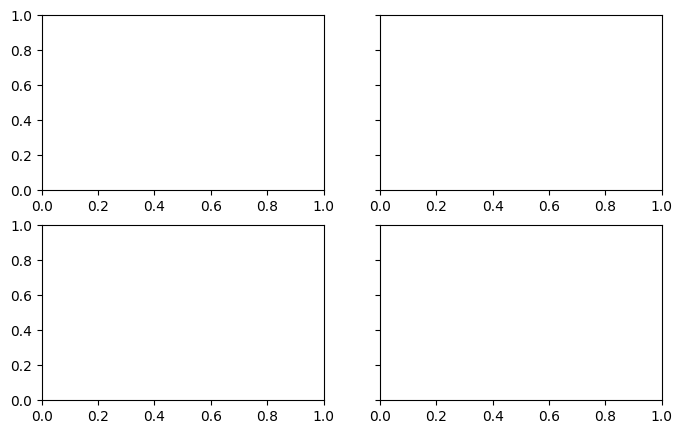

In [22]:
plot_distances_distribution(gestational_df, ["Gestational Diabetes", "Prediabetic state"])

# Tolerance to spelling errors 

## Typos

You can take typos from logs, create them manually or generate ([typo](https://pypi.org/project/typo/)). Anyway, make sure that typos of varoius types are represented.

In [23]:
typos = {
    'biomarkers': 'nbiomarkers',  # лишняя в начале
    'transfusions': 'transfusilons',  # лишняя в середине 
    'ravulizumab': 'ravulizumanb',  # лишняя в конце 
    'clinical trial': 'xlinical trial',  # ошибка в начале
    'meningococcal vaccine': 'meningococcql vacine',  # ошибка в середине
    'thrombosis': 'thrombosie',  # ошибка в конце
    'ozempik': '0zempik',  # похожий символ в начале
    'diagnosis': 'diaqnosis',  # похожий символ в середине 
    'fatigue': 'fatiguc', # похожий символ в конце 
    'patient': 'ptaient',  # char swap в начале
    'myasthenia': 'mysathenia',  # char swap в середине
    'therapy': 'therpay',  # char swap в конце
    'pregnancy': 'regnancy',  # пропуск в начале 
    'symptoms': 'symptos',  # пропуск в середине 
    'epidemiology': 'epidemiolog'  # пропуск в конце 
}

In [24]:
typos_df = pd.DataFrame(list(typos.items()), columns=["word", "typo"])
typos_df.head()

,word,typo
0,biomarkers,nbiomarkers
1,transfusions,transfusilons
2,ravulizumab,ravulizumanb
3,clinical trial,xlinical trial
4,meningococcal vaccine,meningococcql vacine


Processing openai:   0%|          | 0/1 [00:00<?, ?it/s]

Processing openai:   0%|          | 0/1 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/1 [00:00<?, ?it/s]

Processing voyage:   0%|          | 0/1 [00:00<?, ?it/s]

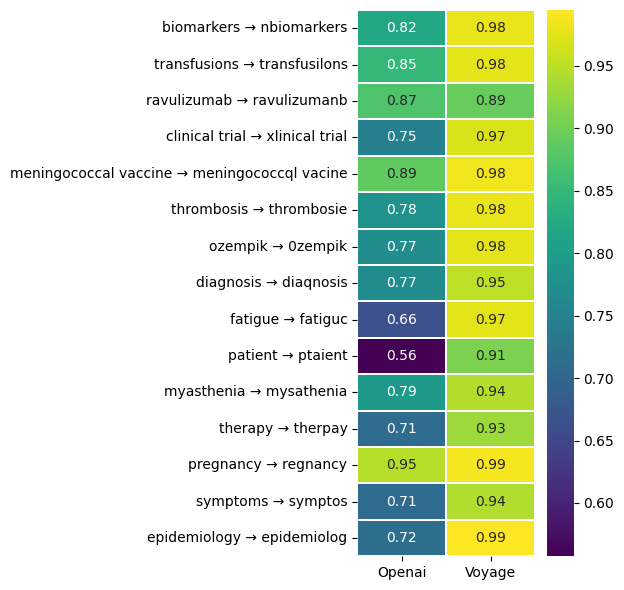

In [25]:
for model, method, _ in methods:
    embeddings_original = get_embeddings(typos_df["word"].tolist(), model, method)
    embeddings_typos = get_embeddings(typos_df["typo"].tolist(), model, method)
    similarity_scores = np.diag(cosine_similarity(embeddings_original, embeddings_typos))
    
    typos_df[model] = similarity_scores

yticklabels = [f"{row['word']} → {row['typo']}" for _, row in typos_df.iterrows()]
scores_matrix = typos_df[[model for model, _, _ in methods]].values

fig, ax = plt.subplots(figsize=(6, len(typos_df) * 0.4))
sns.heatmap(scores_matrix, annot=True, fmt=".2f", yticklabels=yticklabels, 
            xticklabels=[model.capitalize() for model, _, _ in methods], cmap='viridis', linewidths=.25, ax=ax)

plt.tight_layout()
plt.show()

## Tokenization

In [ ]:
for term in typos:
    encoded_term = tokenizer.encode(term)
    decoded_tokens = [tokenizer.decode_single_token_bytes(token).decode('utf-8', errors='replace').strip() for token in encoded_term]
        
    encoded_typo = tokenizer.encode(typos[term])
    decoded_typo_tokens = [tokenizer.decode_single_token_bytes(token).decode('utf-8', errors='replace').strip() for token in encoded_typo]

    print(f"{term}: {'-'.join(decoded_tokens)} / {'-'.join(decoded_typo_tokens)}")

In [ ]:
tokenizers = {
    "openai": openai_tokenizer,
    # "voyageai": voyage_tokenizer
}

results = {}
for tokenizer, tokenizer_func in tokenizers.items():
    tokenizer_results = []
    for term in typos:
        encoded_term = tokenizer_func.encode(term)
        decoded_tokens = [tokenizer_func.decode_single_token_bytes(token).decode('utf-8', errors='replace').strip() for token in encoded_term]
        
        encoded_typo = tokenizer_func.encode(typos[term])
        decoded_typo_tokens = [tokenizer_func.decode_single_token_bytes(token).decode('utf-8', errors='replace').strip() for token in encoded_typo]
        
        tokenizer_results.append(f"{'-'.join(decoded_tokens)} / {'-'.join(decoded_typo_tokens)}")
    results[tokenizer] = tokenizer_results


pd.DataFrame(results, index=typos.keys()).head(20)

# Domain terms

In [ ]:
import nltk
import ssl

ssl._create_default_https_context = ssl._create_unverified_context
nltk.download('wordnet')

from nltk.corpus import wordnet

In [ ]:
words = list(wordnet.words())
len(words)

In [ ]:
# todo remove

words = words.sample(n=300, random_state=42)

In [ ]:
terms = [
    "Selective serotonin reuptake inhibitor",  # Class of antidepressants
    "BBB disruption therapy",  # Method of temporarily disrupting the blood-brain barrier to deliver drugs to brain tissue
    "CAR T-cell therapy",  # Immunotherapy where modified T-cells attack cancer cells
    "Meningococcal vaccine",  # Vaccine against infections causing meningitis
    "Zolgensma",  # Gene therapy for spinal muscular atrophy
    "ReoPro",  # Drug preventing blood clotting during vascular surgeries
    "Rickettsia prowazekii",  # Bacterium causing epidemic typhus
    "Neurofilament light chain",  # Biomarker for diagnosing neurological disorders
    "lncRNA",  # Long non-coding RNAs with gene regulatory functions
    "Antisense oligonucleotide",  # Short synthetic DNA or RNA for therapy of genetic diseases and cancer
    "Gamma Knife procedure",  # Neurological radiosurgery for treating brain tumors
    "Cladribine",  # Drug for treating multiple sclerosis
    "PD-L1 mAbs",  # Monoclonal antibodies helping the immune system recognize and destroy cancer cells
    "Kabuki syndrome"  # Rare genetic disorder
]

In [ ]:
terms_df = pd.DataFrame(terms, columns=["term"])
terms_df.head()

In [ ]:
for model, method, batch_size in methods:
    terms_embeddings = get_embeddings(terms_df["term"].tolist(), model, method)
    wordnet_embeddings = get_embeddings(words, model, method, batch_size)
    similarities = cosine_similarity(terms_embeddings, wordnet_embeddings)
    
    results = []
    for term, term_similarities in zip(terms, similarities):
        top_indices = np.argsort(term_similarities)[-3:][::-1]
        top_words = [words[i] for i in top_indices]
        results.append(", ".join(top_words))
    
    terms_df[model] = results

terms_df.head(20)